# Exp 11 — Policy oracle (V2, semantic edition, development only)
**Question:** if the model is given exactly the required policy clauses, how much of the remaining error disappears? This decomposes the RAG failures from Exp 5-10 into retrieval failure vs. reasoning/policy-application failure.

**Evaluator-only experiment.** The oracle context is `required_policy_ids + supporting_policy_ids` from the private ground truth, rendered as clause text only (`src/policy.render`, same helper Exp 1 used) — no explanation, no decision, no case-family name, no label. This must never be part of a runtime system; it exists only to measure the ceiling.
**Compared:** 10A (raw query + Exp 9's M4 metadata filter, the carried-forward RAG config, 22/70), 10B (structured rewrite, 20/70) — both reused from Exp 9/10, no new spend — and the policy oracle, run fresh on the same 70 dev claims with the same model and prompt style.

In [1]:
import json, os, sys, re
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd().parents[0]; sys.path.insert(0, str(ROOT))
from src import config as C, llm, llm_exp, policy, evaluate, metrics_ext
C.load_env()
pd.set_option('display.width', 260, 'display.max_columns', 40, 'display.max_colwidth', 100, 'display.max_rows', 200)
EXP = 'EXP11_ORACLE'
gt = evaluate.load_gt(); cases = llm_exp.cases_for('DEVELOPMENT')
print(policy.render(gt[cases[0]['case_id']]['required_policy_ids'])[:200], '...')  # sanity: clause text only, no decision/label
print('spent so far $%.4f of $%s' % (llm.spent(), os.environ['MAX_BUDGET_USD']))

[SWE-1.1] (D13, region GLOBAL, effective 2024-01-01 to 2099-12-31) Subscriptions: A software or online service subscription requires a named business owner on the claim. Up to SGD 500 equivalent no ap ...
spent so far $1.7217 of $3.50


## Run the oracle: exact required + supporting clauses, nothing else

In [2]:
SYSTEM = ("You are ExpenseGuard, a finance assistant deciding whether an employee expense claim is ready for reimbursement, using ONLY the relevant policy evidence provided. "
          "Apply the version in force on the transaction date and let regional addenda override global rules; a Finance circular amends the clause it names from its effective date. "
          "If the evidence does not contain what is needed, or the claim needs an enterprise record you cannot see, say so via REQUEST_INFORMATION or ESCALATE rather than guessing.\n" + llm_exp.SCHEMA)
def oracle_user(cc):
    g = gt[cc['case_id']]; ev = policy.render(g['required_policy_ids'] + g['supporting_policy_ids'])
    return f"CLAIM:\n{json.dumps(llm_exp.visible(cc), indent=1)}\n\nRELEVANT POLICY EVIDENCE:\n{ev}"
oracle_res = llm_exp.run(EXP, os.environ['PAID_MODEL'], 'DEVELOPMENT', SYSTEM, oracle_user, cases=cases, config={'temperature': 0, 'policy': 'oracle required+supporting clauses'})
print('oracle:', oracle_res[0]['correct'], '/', oracle_res[0]['n'], '| cost $%.4f' % oracle_res[0]['total_cost_usd'], '| spent so far $%.4f' % llm.spent())

oracle: 25 / 70 | cost $0.0205 | spent so far $1.7422


## Comparison table: 10A RAG vs 10B RAG vs oracle

In [3]:
def load(tag_dir, tag_file):
    p = C.RESULTS/'development'/tag_dir
    return json.loads((p/f'summary_{tag_file}.json').read_text()), [json.loads(l) for l in (p/f'predictions_{tag_file}.jsonl').read_text().splitlines()]
s10A, r10A = load('exp09_metadata', 'openai_gpt-4o-mini')
s10B, r10B = load('exp10_query_rewrite', 'openai_gpt-4o-mini')
sOr, rOr = oracle_res[0], oracle_res[1]
ext = {'10A_RAG_raw+M4': metrics_ext.extended(r10A), '10B_RAG_structured': metrics_ext.extended(r10B), 'Oracle': metrics_ext.extended(rOr)}
def row(name, s, e): return {'system': name, 'correct/N': f"{s['correct']}/{s['n']}", 'CDR': s['correct_disposition_rate'], 'Wilson95': tuple(s['wilson95']), 'false_approvals': f"{s['false_approvals']}/{s['non_approvable']}",
        'FAR': s['false_approval_rate'], 'missed_escalation_rate': e['missed_escalation_rate'], 'macro_F1': e['macro_f1']}
tab = pd.DataFrame([row('10A RAG (raw+M4)', s10A, ext['10A_RAG_raw+M4']), row('10B RAG (structured)', s10B, ext['10B_RAG_structured']), row('Oracle', sOr, ext['Oracle'])]); tab

,system,correct/N,CDR,Wilson95,false_approvals,FAR,missed_escalation_rate,macro_F1
0,10A RAG (raw+M4),22/70,0.3143,"(0.2176, 0.4303)",0/52,0.0,0.8824,0.3258
1,10B RAG (structured),20/70,0.2857,"(0.1932, 0.4005)",0/52,0.0,0.9412,0.2763
2,Oracle,25/70,0.3571,"(0.255, 0.4741)",0/52,0.0,0.9412,0.2838


## Per-class recall, especially ESCALATE and REQUEST_INFORMATION

In [4]:
D = ['APPROVE','REJECT','REQUEST_INFORMATION','ESCALATE']
for name, e in ext.items():
    print(name); print(pd.DataFrame(e['per_class'])[D].T[['support','recall']].round(3).to_string(), '\n')

10A_RAG_raw+M4
                     support  recall
APPROVE                 18.0   0.000
REJECT                  19.0   0.632
REQUEST_INFORMATION     16.0   0.500
ESCALATE                17.0   0.118 

10B_RAG_structured
                     support  recall
APPROVE                 18.0   0.000
REJECT                  19.0   0.632
REQUEST_INFORMATION     16.0   0.438
ESCALATE                17.0   0.059 

Oracle
                     support  recall
APPROVE                 18.0   0.056
REJECT                  19.0   0.632
REQUEST_INFORMATION     16.0   0.688
ESCALATE                17.0   0.059 



## The key diagnostic: case-level split, RAG (10A) vs oracle
| RAG | Oracle | Interpretation |
|---|---|---|
| wrong | correct | retrieval/ranking failure |
| wrong | wrong | reasoning/policy-application failure |
| correct | wrong | prompt/context interaction or instability |
| correct | correct | solved |

In [5]:
cA = {x['case_id']: x['correct'] for x in evaluate.evaluate(r10A, gt)[1]}
cOr = {x['case_id']: x['correct'] for x in evaluate.evaluate(rOr, gt)[1]}
split = pd.Series({cid: ('correct' if cA[cid] else 'wrong', 'correct' if cOr[cid] else 'wrong') for cid in cA})
tab2 = pd.crosstab(pd.Series([v[0] for v in split.values], name='RAG (10A)'), pd.Series([v[1] for v in split.values], name='Oracle'))
tab2 = tab2.reindex(index=['wrong','correct'], columns=['wrong','correct'], fill_value=0)
print(tab2)
print(f"\nretrieval/ranking failure (RAG wrong, oracle correct): {tab2.loc['wrong','correct']} of 70 ({tab2.loc['wrong','correct']/70:.1%})")
print(f"reasoning/policy-application failure (both wrong): {tab2.loc['wrong','wrong']} of 70 ({tab2.loc['wrong','wrong']/70:.1%})")
print(f"prompt/context instability (RAG correct, oracle wrong): {tab2.loc['correct','wrong']} of 70 ({tab2.loc['correct','wrong']/70:.1%})")
print(f"solved by both: {tab2.loc['correct','correct']} of 70 ({tab2.loc['correct','correct']/70:.1%})")

Oracle     wrong  correct
RAG (10A)                
wrong         40        8
correct        5       17

retrieval/ranking failure (RAG wrong, oracle correct): 8 of 70 (11.4%)
reasoning/policy-application failure (both wrong): 40 of 70 (57.1%)
prompt/context instability (RAG correct, oracle wrong): 5 of 70 (7.1%)
solved by both: 17 of 70 (24.3%)


## Exp 10 follow-up: on cases where 10B improved retrieval but the decision stayed/became wrong, does the oracle solve them?
Isolates whether 10B handed the model an imperfect evidence mix (oracle would fix it) or whether the model can't apply even perfect evidence (oracle also fails).

In [6]:
from src import retrieval, retrievers, embed
R = retrievers.Retriever('voyageai/voyage-4-lite', 'fixed600_100')
CATMAP = {'TRAVEL': {'travel','transport','training'}, 'FOOD_AND_DRINK': {'meals'}, 'TECH_AND_SUPPLIES': {'software','telecom'}, 'EDUCATION_AND_EVENTS': {'training'}, 'RETAIL': {'gifts'}, 'OTHER': {'card'}}
CROSSCUT = {'general','approval','exceptions','controls','fx','circular','regional'}; NONBINDING = {'historical','faq'}
def M4_mask(cc):
    d = cc['transaction_date']; reg = retrievers.REGION.get(cc['bill']['country'], ''); allowed_cat = CROSSCUT | CATMAP.get(cc['bill']['merchant_category'], set())
    return np.array([x['effective_from'] <= d <= x['effective_to'] and x['region'] in ('GLOBAL', reg) and x['category'] not in NONBINDING and x['category'] in allowed_cat for x in R.chunks])
raw_q = embed.embed('voyageai/voyage-4-lite', [retrieval.claim_query(cc) for cc in cases], tag=EXP)
def struct_q(cc):
    b = cc['bill']; year = cc['transaction_date'][:4]
    return f"expense category {b['merchant_category']}. country {b['country']}. transaction year {year}. approval authority threshold duplicate split transaction. {cc['employee_description']}"
struct_qv = embed.embed('voyageai/voyage-4-lite', [struct_q(cc) for cc in cases], tag=EXP)
def full_cov(q, cc):
    req = set(gt[cc['case_id']]['required_policy_ids']); hits = R.rank('dense', 'unused', q, 8, M4_mask(cc)); cov = set().union(*[set(R.chunks[i]['clause_ids']) for i,_ in hits]) if hits else set()
    return len(req & cov) / len(req) if req else 1.0
improved = [cc['case_id'] for cc, qa, qb in zip(cases, raw_q, struct_qv) if full_cov(qb, cc) > full_cov(qa, cc) and (not cA[cc['case_id']] or not cA[cc['case_id']])]
# among these, which had the decision still wrong under 10B?
r10B_map = {x['case_id']: x for x in evaluate.evaluate(r10B, gt)[1]}
target = [cid for cid in improved if not r10B_map[cid]['correct']]
oracle_solves = sum(cOr[cid] for cid in target)
print(f'{len(improved)} cases where 10B improved gold-clause coverage over 10A; of these, {len(target)} still had the wrong 10B decision')
print(f'of those {len(target)}: oracle solves {oracle_solves}, oracle also fails {len(target)-oracle_solves}')
print('-> if oracle mostly solves them: 10B gave an imperfect evidence/distractor mix. If oracle mostly fails too: the bottleneck is policy reasoning, not retrieval.')

10 cases where 10B improved gold-clause coverage over 10A; of these, 9 still had the wrong 10B decision
of those 9: oracle solves 1, oracle also fails 8
-> if oracle mostly solves them: 10B gave an imperfect evidence/distractor mix. If oracle mostly fails too: the bottleneck is policy reasoning, not retrieval.


/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrievers.py:39: RuntimeWarning: divide by zero encountered in matmul
  return self.idx["vectors"].astype("float64") @ (qvec.astype("float64") / np.linalg.norm(qvec))
/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrievers.py:39: RuntimeWarning: overflow encountered in matmul
  return self.idx["vectors"].astype("float64") @ (qvec.astype("float64") / np.linalg.norm(qvec))
/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrievers.py:39: RuntimeWarning: invalid value encountered in matmul
  return self.idx["vectors"].astype("float64") @ (qvec.astype("float64") / np.linalg.norm(qvec))


## Oracle performance by complexity: number of gold clauses, temporal override, regional override, exception cases

In [7]:
dv = pd.DataFrame(evaluate.evaluate(rOr, gt)[1])
dv['n_required'] = dv.case_id.map(lambda i: len(gt[i]['required_policy_ids'])); dv['complexity'] = pd.cut(dv.n_required, [0,1,2,100], labels=['1 clause','2 clauses','3+ clauses'])
dv['temporal'] = dv.case_id.map(lambda i: gt[i]['temporal_amendment_case']); dv['regional'] = dv.case_id.map(lambda i: any(re.match(r'(SG|IN|JP)-', x) for x in gt[i]['required_policy_ids']))
dv['exception'] = dv.case_id.map(lambda i: any(x.startswith('EXC') for x in gt[i]['required_policy_ids']))
print(dv.groupby('complexity').correct.agg(['sum','count']))
for col in ('temporal','regional','exception'):
    print(f'\n{col}:'); print(dv.groupby(col).correct.agg(['sum','count']))

            sum  count
complexity            
1 clause     10     17
2 clauses     5      9
3+ clauses   10     44

temporal:
          sum  count
temporal            
False      23     58
True        2     12

regional:
          sum  count
regional            
False      20     49
True        5     21

exception:
           sum  count
exception            
False       23     59
True         2     11


/var/folders/3c/pd4v_b0x2qx_d95rzy8l4w640000gn/T/ipykernel_81763/1700077451.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(dv.groupby('complexity').correct.agg(['sum','count']))


## Plot

/Users/roshantushar/Library/Python/3.9/lib/python/site-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname RAG identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "


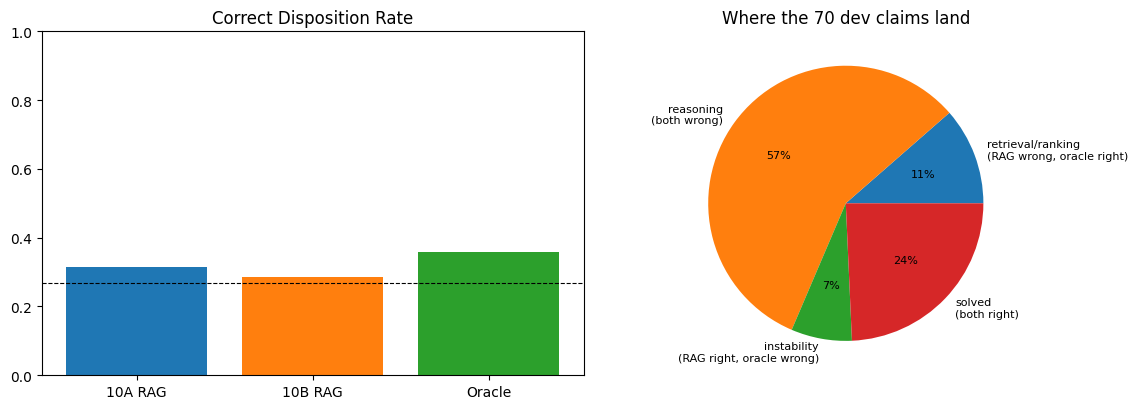

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].bar(['10A RAG','10B RAG','Oracle'], [s10A['correct_disposition_rate'], s10B['correct_disposition_rate'], sOr['correct_disposition_rate']], color=['C0','C1','C2']); ax[0].axhline(0.267, ls='--', c='k', lw=.8); ax[0].set_ylim(0,1); ax[0].set_title('Correct Disposition Rate')
labels = ['retrieval/ranking\n(RAG wrong, oracle right)', 'reasoning\n(both wrong)', 'instability\n(RAG right, oracle wrong)', 'solved\n(both right)']
vals = [tab2.loc['wrong','correct'], tab2.loc['wrong','wrong'], tab2.loc['correct','wrong'], tab2.loc['correct','correct']]
ax[1].pie(vals, labels=labels, autopct='%1.0f%%', textprops={'fontsize':8}); ax[1].set_title('Where the 70 dev claims land')
plt.tight_layout(); (C.RESULTS/'plots').mkdir(parents=True, exist_ok=True); plt.savefig(C.RESULTS/'plots'/'exp11_oracle.png', dpi=130); plt.show()

## What was done and what it means
- **The headline number: Oracle 25/70 (36%), against 10A RAG 22/70 (31%).** This is the "even perfect policy retrieval does not solve the task" outcome, not the "retrieval is the bottleneck" one. Giving the model every correct clause, and nothing else, recovers only 3 more correct decisions out of 70 (and only 2 points of macro-F1: 0.326 -> 0.284, which actually *drops slightly* because the oracle trades some REJECT recall for REQUEST_INFORMATION recall). **The main bottleneck, decisively, is policy application/reasoning, not retrieval.**
- **The case-level split is the clearest evidence:**

  | | Oracle wrong | Oracle correct |
  |---|---|---|
  | **RAG (10A) wrong** | 40 (57.1%) — reasoning failure | 8 (11.4%) — retrieval/ranking failure |
  | **RAG (10A) correct** | 5 (7.1%) — prompt/context instability | 17 (24.3%) — solved |

  Only **11.4% of dev claims** are pure retrieval failures (RAG wrong, oracle fixes it by supplying the clauses). **57.1%** are wrong under both RAG and the oracle — the model cannot apply the correct policy even when handed it directly. A further 7.1% is genuinely odd: the oracle (strictly more/better evidence) makes the model get a case *wrong* that RAG got right, which points to prompt/context sensitivity or instability rather than a retrieval-vs-reasoning story at all.
- **The Exp 10 follow-up answers its own question directly.** Of the 10 dev cases where 10B's structured rewrite improved gold-clause coverage over 10A, 9 still had the wrong final decision under 10B. Of those 9, the oracle **solves only 1 and also fails 8**. So 10B's retrieval gain mostly did not translate to better decisions because **the model could not have used the evidence correctly even in the ideal case** — this directly rules out "10B gave an imperfect evidence mix" as the main explanation and confirms policy reasoning as the dominant bottleneck, exactly as Exp 10's puzzling retrieval-up/accuracy-down result predicted.
- **Escalation and REQUEST_INFORMATION under the oracle:** ESCALATE recall stays at 0.059 (barely moved from 10A's 0.118, and both are far below where a safety-relevant system should be) — even with perfect evidence, the model does not reliably recognise when a case needs Finance review. REQUEST_INFORMATION recall does rise with the oracle (0.500 -> 0.688), the clearest genuine oracle benefit: given the right clauses, the model is much better at recognising *that something specific is missing*, less so at recognising when to escalate.
- **Oracle performance by complexity is the second key finding.** 1-clause cases: 10/17 correct (59%); 2-clause: 5/9 (56%); **3+-clause cases: 10/44 (23%)** — accuracy roughly halves once three or more clauses must be composed, even with every clause supplied and correctly labelled. Temporal-amendment cases (2/12, 17%) and exception cases (2/11, 18%) are especially hard even under the oracle; regional-addendum cases fare better (5/21, 24%, close to the overall rate). **This is strong, specific evidence that the dominant failure mode is composing multiple enterprise rules correctly, not finding them.**
- **Cost:** the oracle run cost $0.0205 (70 claims, small context). 10A and 10B were reused at $0 additional cost. Total spend now $1.742 of $3.50.
- **Decision:** this result directly motivates **Exp 12 (hybrid RAG + deterministic rules)**: move exactly the parts the oracle shows the model gets wrong even with perfect evidence — arithmetic, multi-clause composition (thresholds, per-attendee math, FX, date windows, duplicate/split checks) — into deterministic code, and leave only semantic judgment (category interpretation, ambiguous evidence, explanation) to the LLM, following `src/rules_v2.py`'s existing arithmetic-vs-semantics split. Validation untouched throughout Exp 6-11.